In [2]:
pip install fpppy

   ---------------------------------------- 0.0/5.8 MB ? eta -:--:--
   ---------------------------------------- 5.8/5.8 MB 35.7 MB/s eta 0:00:00

   ----------------------------------------  0/12 [distlib]
   ----------------------------------------  0/12 [distlib]
   ----------------------------------------  0/12 [distlib]
  Attempting uninstall: platformdirs
   ----------------------------------------  0/12 [distlib]
    Found existing installation: platformdirs 4.2.0
   ----------------------------------------  0/12 [distlib]
    Uninstalling platformdirs-4.2.0:
   ----------------------------------------  0/12 [distlib]
      Successfully uninstalled platformdirs-4.2.0
   ----------------------------------------  0/12 [distlib]
   --- ------------------------------------  1/12 [platformdirs]
   --- ------------------------------------  1/12 [platformdirs]
   ------ ---------------------------------  2/12 [nodeenv]
   ---------- -----------------------------  3/12 [identify]
   ---


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#569CC6", "#D55F03"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [24]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#2f2fff"])
import statsmodels.api as sm
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf

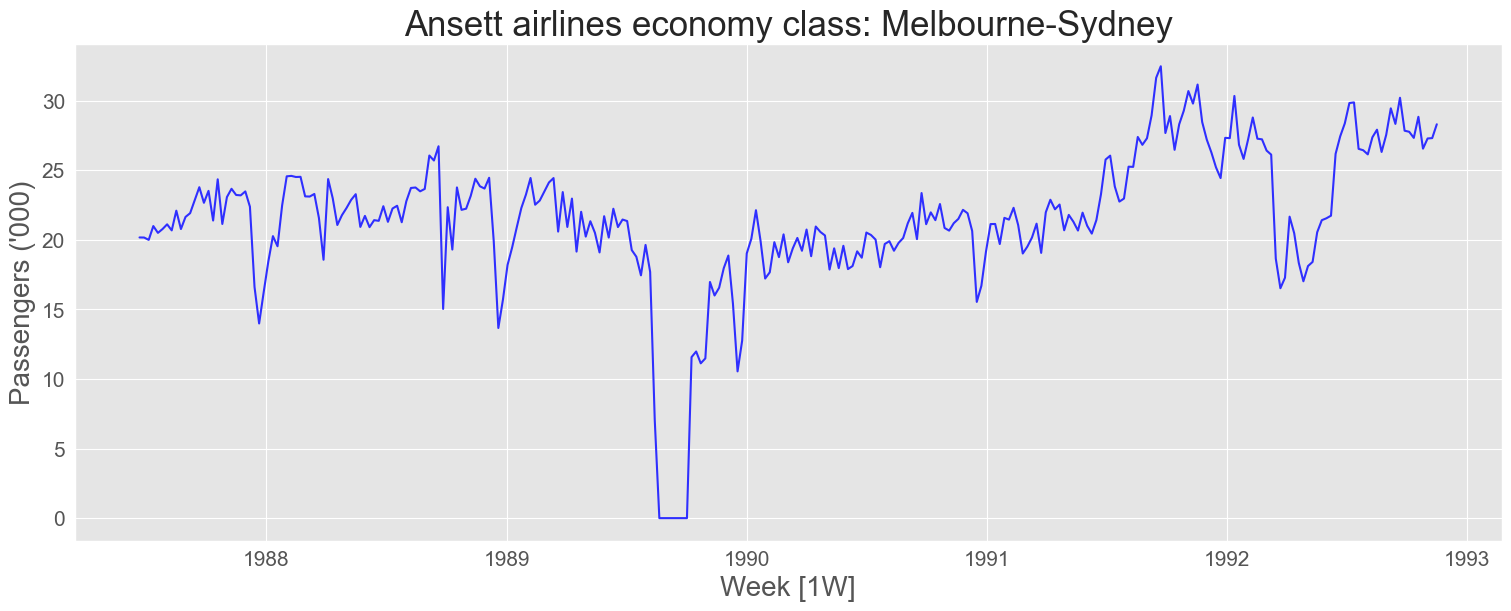

In [6]:
melsyd_economy = (
    pd.read_csv("ansett.csv", parse_dates=["ds"])
    .loc[lambda x: (x["Airports"] == "MEL-SYD")
        & (x["Class"] == "Economy")]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
)
plot_series(
    df=melsyd_economy, id_col="unique_id", time_col="ds", target_col="y",
    xlabel="Week [1W]", ylabel="Passengers ('000)",
    title="Ansett airlines economy class: Melbourne-Sydney")

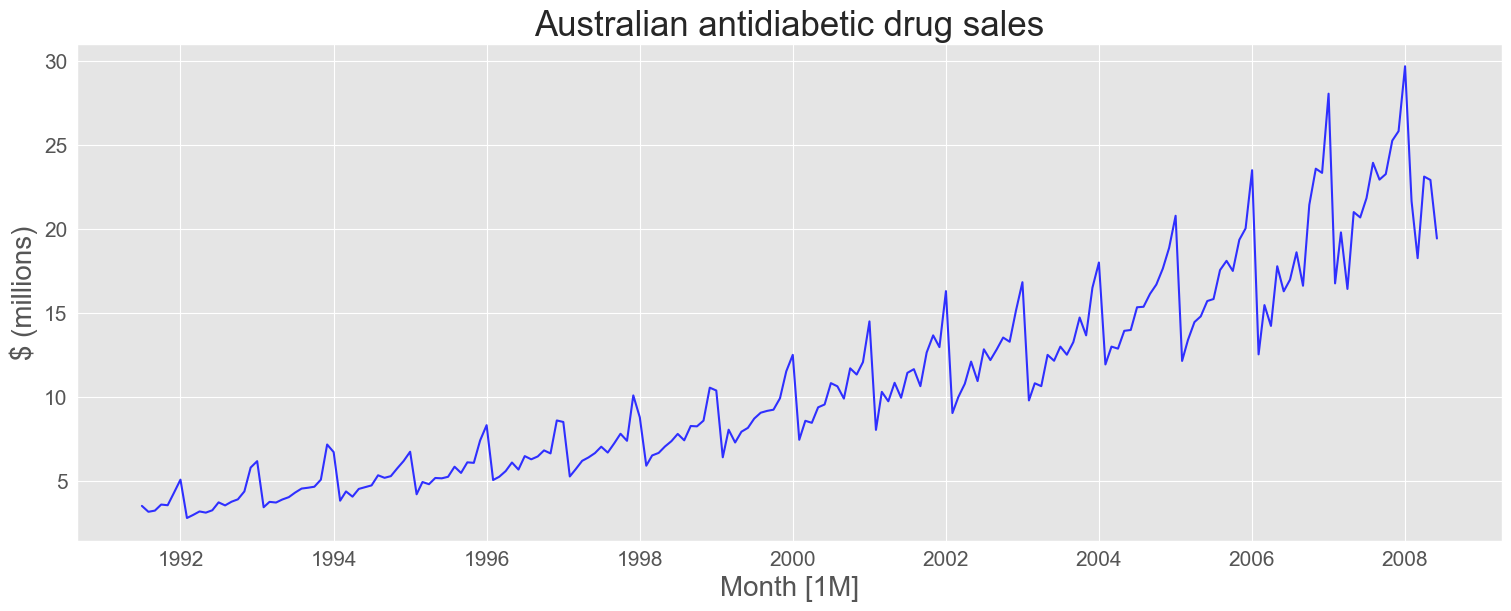

In [9]:
pbs = (
    pd.read_csv("PBS_unparsed.csv", parse_dates=["Month"])
    [["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]
)

total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .assign(Cost=lambda x: (x["Cost"] / 1e6).round(2))
)

plot_series(total_cost_df.assign(unique_id="total_cost"),
    time_col="Month", target_col="Cost",
    xlabel="Month [1M]", ylabel="$ (millions)",
    title="Australian antidiabetic drug sales")

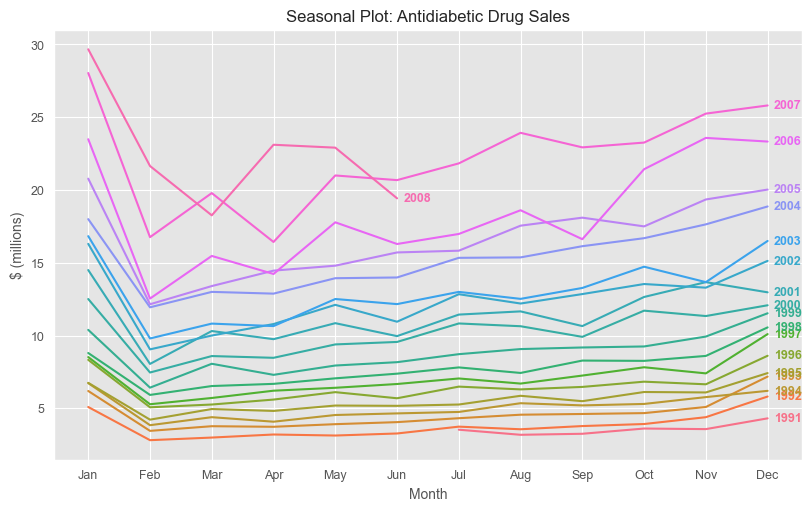

In [10]:
df = total_cost_df.assign(
    Month_name=total_cost_df["Month"].dt.strftime("%b"),
    Year=total_cost_df["Month"].dt.year,
    Month_num=total_cost_df["Month"].dt.month,
)
unique_years = df["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))
fig, ax = plt.subplots()
sns.lineplot(data=df, x="Month_num", y="Cost",
  hue="Year", palette=year_palette, legend=False, ax=ax)

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)
min_year = unique_years.min()
for year, subset in df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Cost"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="center", fontsize=9, weight="bold", color=color)
fig.show()

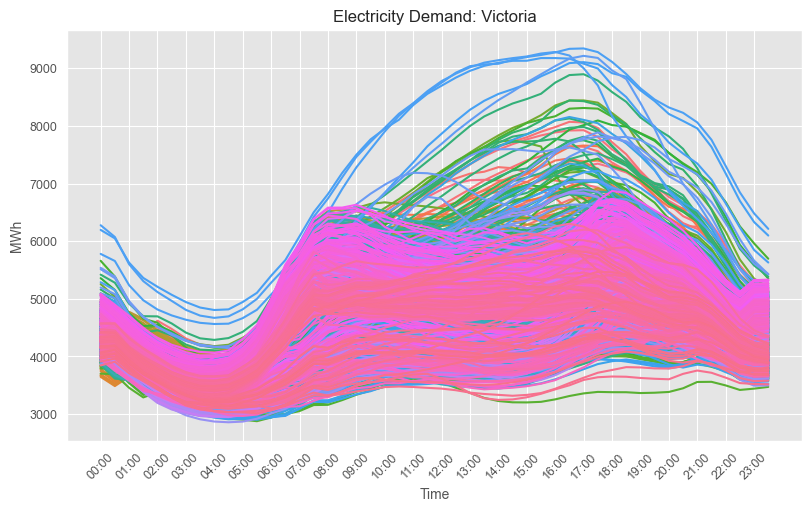

In [11]:
vic_elec_df = pd.read_csv("vic_elec.csv", parse_dates=["ds"])
vic_elec_demand = vic_elec_df[vic_elec_df["unique_id"] == "Demand"]
df = vic_elec_demand.assign(
    hour_minute=lambda x: x["ds"].dt.strftime("%H:%M"),
    day=lambda x: x["ds"].dt.date,
)

fig, ax = plt.subplots()
sns.lineplot(data=df, x="hour_minute", y="y",
    hue="day", palette="husl", legend=False, ax=ax)
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)
unique_ticks = df["hour_minute"].unique()
ticks = range(0, len(unique_ticks), 2)
ticklabels = unique_ticks[::2]
ax.set_xticks(ticks, labels=ticklabels, rotation=45)
fig.show()

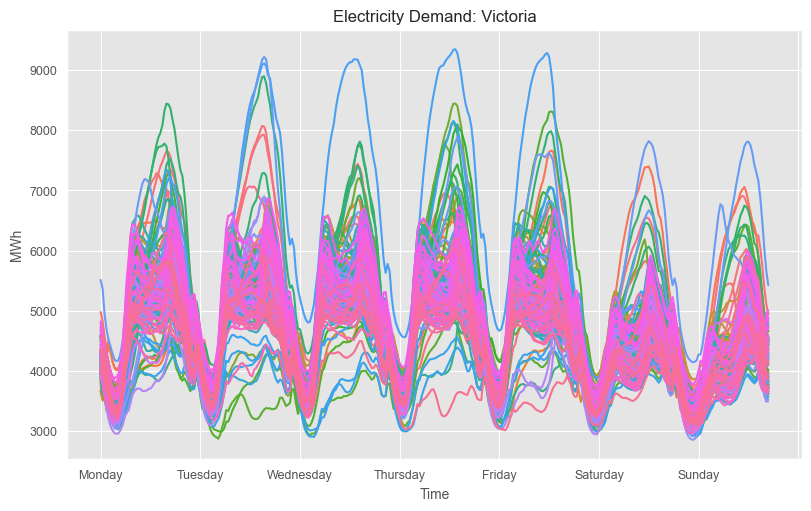

In [12]:
df = (
    vic_elec_demand
    .loc[lambda x: x["ds"].between("2012-01-02", "2014-12-28 23:59")]
    .assign(
        day_of_week=lambda x: x["ds"].dt.day_name(),
        week=lambda x: x["ds"].dt.to_period("W").dt.start_time,
    )
)
unique_weeks = df["week"].unique()
palette = sns.color_palette("husl", n_colors=len(unique_weeks))
color_map = dict(zip(unique_weeks, palette))

fig, ax = plt.subplots()
for week, df_week in df.groupby("week"):
    df_week.plot(x="day_of_week", y="y",
        ax=ax, color=color_map[week])
ax.get_legend().remove()
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)
fig.show()

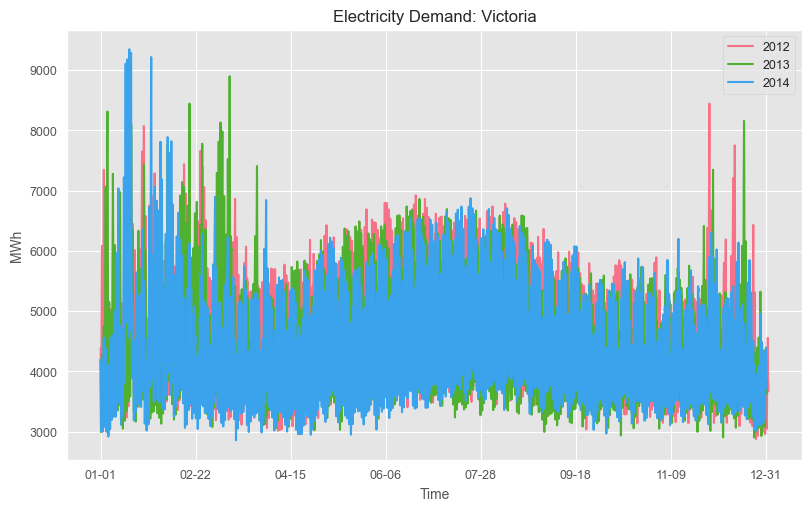

In [13]:
df = vic_elec_demand.assign(
    day_of_year=lambda x: x["ds"].dt.strftime("%m-%d"),
    year=lambda x: x["ds"].dt.year,
)

palette = sns.color_palette("husl", n_colors=df["year"].nunique())
fig, ax = plt.subplots()
for i_year, (year, df_year) in enumerate(df.groupby("year")):
    df_year.plot(x="day_of_year", y="y", ax=ax,
        label=str(year), color=palette[i_year])
ax.set(
    title="Electricity Demand: Victoria",
    ylabel="MWh",
    xlabel="Time",
)
fig.show()

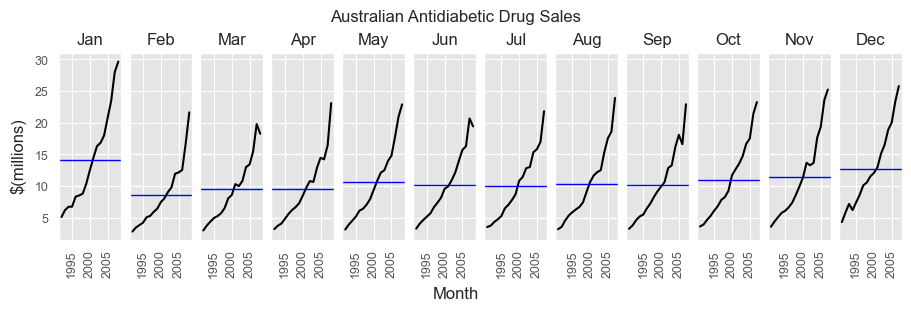

In [14]:
df = total_cost_df.assign(
    year=total_cost_df["Month"].dt.year,
    month_name=total_cost_df["Month"].dt.month_name(),
    month_idx=total_cost_df["Month"].dt.month,
)

fig, axes = plt.subplots(1, 12, figsize=(9, 3), sharey=True)
for ax, ((_, month_name), month_df) in zip(
        axes, df.groupby(["month_idx", "month_name"])):
    mean_cost = month_df["Cost"].mean()
    ax.plot(month_df["year"], month_df["Cost"], color="k")
    ax.axhline(mean_cost, color="b", linewidth=1)
    ax.set(title=month_name[:3], xlabel="")
    ax.tick_params(axis="x", rotation=90)

fig.suptitle("Australian Antidiabetic Drug Sales")
fig.supxlabel("Month")
fig.supylabel("$(millions)")
fig.show()

In [15]:
tourism = pd.read_csv("tourism.csv", parse_dates=["ds"])
trips = (
    tourism.loc[lambda x: x["Purpose"] == "Holiday"]
    .groupby(["State", "ds"], as_index=False)
    .agg({"y": "sum"})
)
trips

,State,ds,y
0,ACT,1998-01-01,196.219
1,ACT,1998-04-01,126.771
2,ACT,1998-07-01,110.680
3,ACT,1998-10-01,170.472
4,ACT,1999-01-01,107.779
...,...,...,...
635,Western Australia,2016-10-01,982.753
636,Western Australia,2017-01-01,1134.352
637,Western Australia,2017-04-01,997.852
638,Western Australia,2017-07-01,879.989


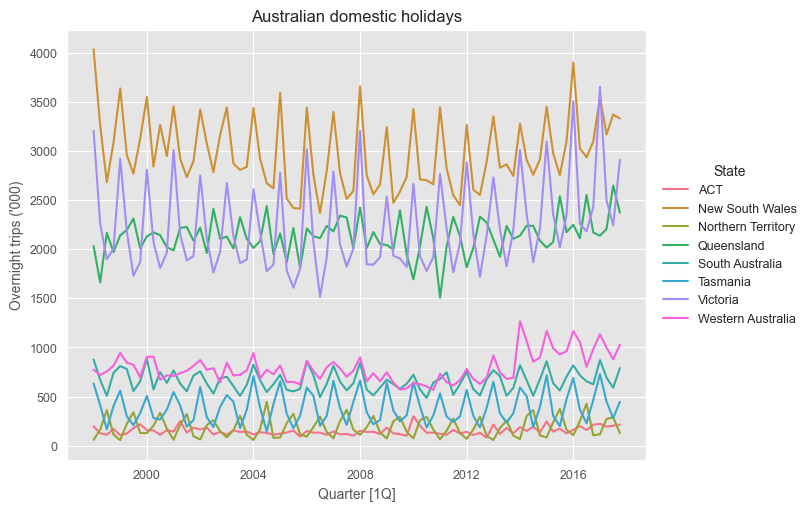

In [16]:
fig, ax = plt.subplots()
palette = sns.color_palette("husl", trips["State"].nunique())
sns.lineplot(data=trips, x="ds", y="y", hue="State", palette=palette)
ax.set(
    title="Australian domestic holidays",
    ylabel="Overnight trips ('000)",
    xlabel="Quarter [1Q]",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, borderaxespad=0, title="State")
fig.show()

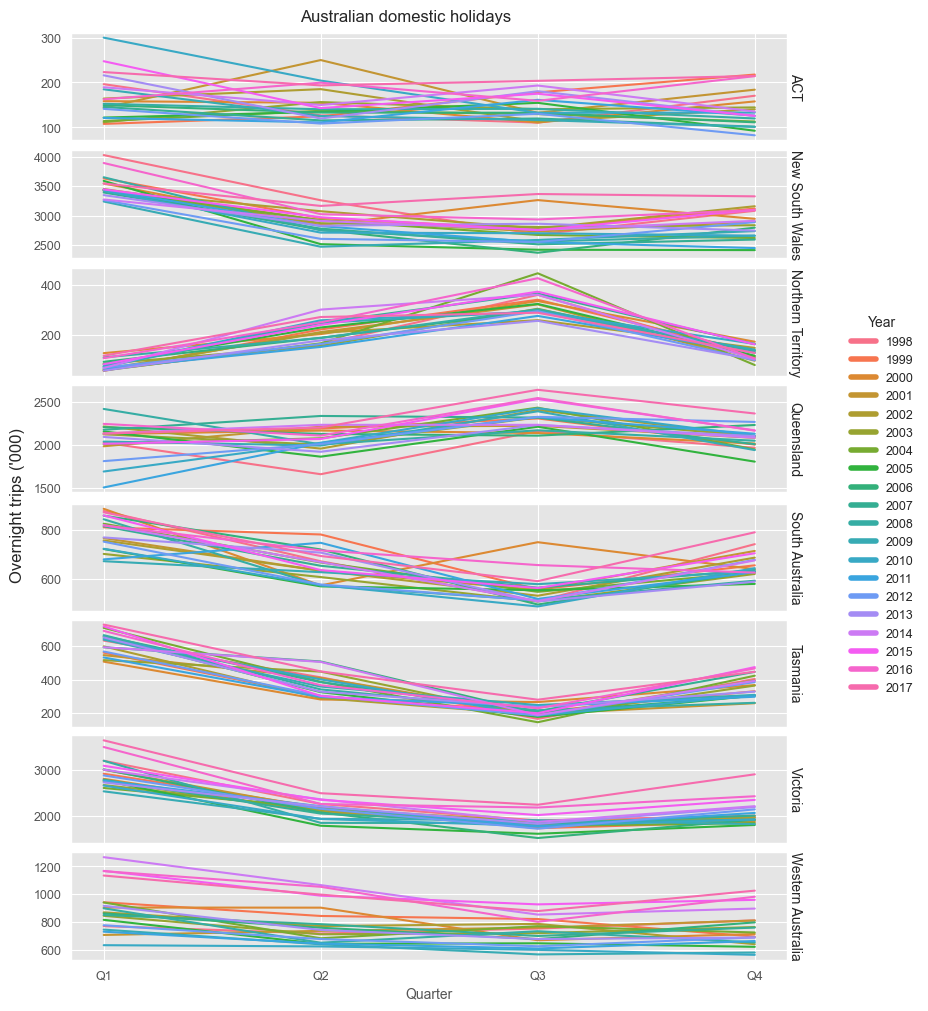

In [17]:
df = trips.assign(
    Quarter="Q" + trips["ds"].dt.quarter.astype("string"),
    Year=trips["ds"].dt.year,
)
num_states, num_years = df[["State", "Year"]].nunique()
palette = sns.color_palette("husl", num_years)
fig, axes = plt.subplots(num_states, sharex=True, figsize=(8, 10))
for ax, (state, state_df) in zip(axes, df.groupby("State")):
    sns.lineplot(data=state_df, x="Quarter", y="y",
        hue="Year", palette=palette, ax=ax)
    ax.get_legend().remove()
    ax.set(ylabel="")
    ax.text(1.02, 0.5, state, va="center", ha="right", rotation=270,
        size="medium", transform=ax.transAxes)
handles, labels = ax.get_legend_handles_labels()
for h in handles:
    h.set(linewidth=4)
fig.legend(handles, labels, title="Year", loc="center left",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.suptitle("Australian domestic holidays")
fig.supylabel("Overnight trips ('000)")
fig.show()

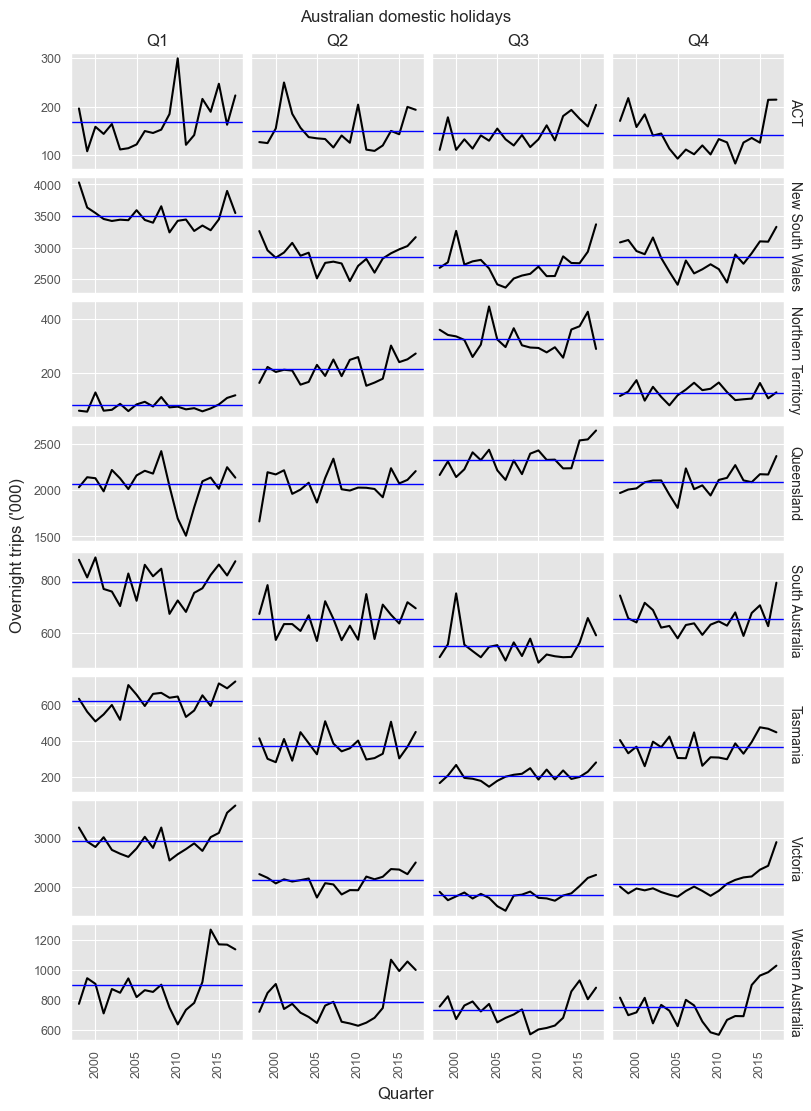

In [18]:
fig, axes = plt.subplots(num_states, 4,
    sharex=True, sharey="row", figsize=(8, 11))
for ax, ((state, quarter), sq_df) in zip(
        axes.flat, df.groupby(["State", "Quarter"])):
    ax.plot(sq_df["Year"], sq_df["y"], color="k")
    ax.axhline(sq_df["y"].mean(), color="b", linewidth=1)
    ax.tick_params(axis="x", rotation=90)
    xticks = sq_df["Year"].loc[lambda x: (x % 5) == 0]
    if ax in axes[0]:
        ax.set(title=quarter, xticks=xticks)
    if ax in axes[:, -1]:
        ax.text(1.02, 0.5, state, va="center", ha="left", rotation=270,
            size="medium", transform=ax.transAxes)
fig.suptitle("Australian domestic holidays")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")
fig.show()

Text(0.02, 0.5, 'Beer')

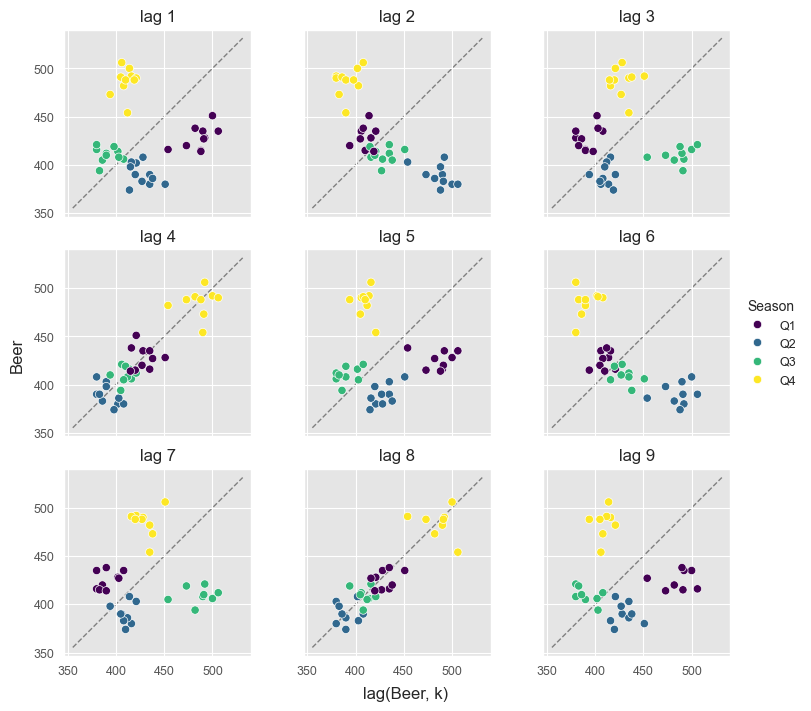

In [19]:
beer = (
    pd.read_csv("aus_production.csv", parse_dates=["ds"])
    [["ds", "Beer"]]
    .loc[lambda x: x["ds"] >= "2000"]
    .assign(Season=lambda x: "Q" + x["ds"].dt.quarter.astype("string"))
    .rename(columns={"Beer": "y"})
)
lims = .95 * beer["y"].min(), 1.05 * beer["y"].max()

cmap = plt.get_cmap("viridis")
colors = {
    season: cmap(i / 3)
    for i, season in enumerate(beer["Season"].unique())
}

fig, axes = plt.subplots(3, 3, figsize=(8, 7), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    lag = i + 1
    df = beer.assign(lag=beer["y"].shift(lag))

    sns.scatterplot(data=df, x="lag", y="y", hue="Season",
        palette=colors, ax=ax)
    ax.plot(lims, lims, color=".5", ls="--", lw=1, zorder=-1)
    ax.set(title=f"lag {lag}", xlabel="", ylabel="", aspect="equal")
    ax.get_legend().remove()
axes[1, -1].legend(loc="center left", title="Season",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.supxlabel("lag(Beer, k)")
fig.supylabel("Beer")

In [ ]:
acf = sm.tsa.acf(beer["y"], nlags=9, fft=False, bartlett_confint=False)
acf_df = pd.Series(acf, name="ACF").to_frame().rename_axis("lag")
acf_df[1:]

,ACF
lag,
1,-0.053
2,-0.758
3,-0.026
4,0.802
5,-0.077
6,-0.657
7,0.001
8,0.707
9,-0.089


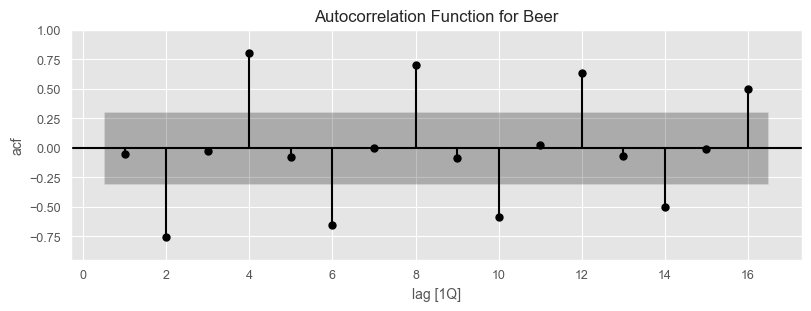

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(beer["y"], lags=16, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=True)
ax.set(
    title="Autocorrelation Function for Beer",
    xlabel="lag [1Q]", ylabel="acf",
)
fig.show()